# **DataHacks 2026**

## **Are marine life datasets biased toward specific ocean chemical conditions?**

## Datasets Used

Dataset 1: Dissolved Inorganic Carbon & Total Alkalinity

- Collected samples and measurements of inorganic carbon and total alkalinity
- Both help determine the pH levels of water

Dataset 2: OBIS Seamap Dataset Points

- Represents locations and times of observations of marine life species
- Includes species like turtles, birds, etc.

### Let's start with our necessary imports in order to work with our datasets!

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.spatial import cKDTree

### Now let's read in our datasets

In [ ]:
chem_df = pd.read_csv("CALCOFI_DIC_20250122.csv") # dataset 1
seamap_p_df = pd.read_csv("obis_seamap_dataset_507_points.csv") # dataset 2

## Data Cleaning

In [ ]:
# Cleaning dataset 1
chem_df = chem_df.iloc[1:].reset_index(drop=True)
chem_df = chem_df.replace(-999, np.nan)
chem_df = chem_df.drop(columns=['EXPOCODE', 'Ship_Name', 'Station_ID'])
chem_cols = ['DIC', 'TA', 'CTDTEMP_ITS90', 'Salinity_PSS78', 'Latitude', 'Longitude']
for col in chem_cols:
    chem_df[col] = pd.to_numeric(chem_df[col], errors='coerce')

chem_df = chem_df.dropna(subset=chem_cols)

# Cleaning dataset 2
seamap_df = seamap_df.drop(columns=['dataset_id', 'row_id', 'series_id', 'itis_tsn', 'lprecision', 'tprecision', 'notes', 'last_mod', 'timezone', 'provider', 'platform', 'oceano'])
seamap_df['date_time'] = pd.to_datetime(seamap_df['date_time'], errors='coerce')
seamap_df = seamap_df.dropna(subset=['date_time'])
seamap_df = seamap_df.dropna(subset=['latitude', 'longitude'])
seamap_cols = ['latitude', 'longitude']
for col in seamap_cols:
    seamap_df[col] = pd.to_numeric(seamap_df[col], errors='coerce')

## Visualizations

### OBIS Sampling Intensity Heatmap

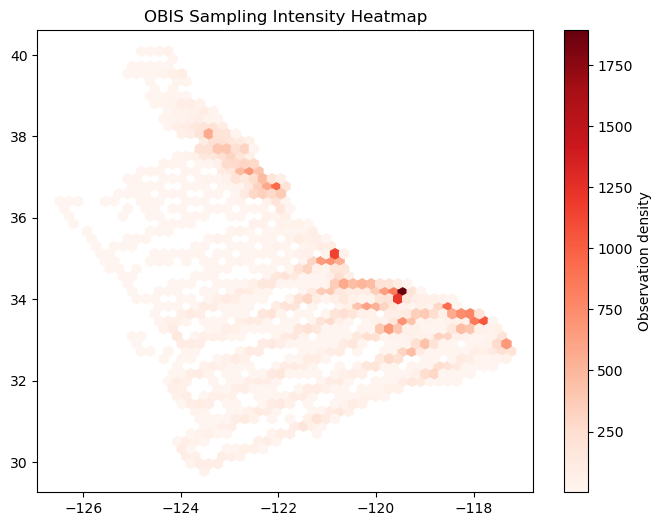

In [ ]:
plt.figure(figsize=(8,6))

plt.hexbin(
    seamap_df['longitude'],
    seamap_df['latitude'],
    gridsize=50,
    cmap='Reds',
    # mincnt=1
)

plt.colorbar(label="Observation density")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("OBIS Sampling Intensity Heatmap")
plt.show()

A heatmap was used here to see how often and where observations were being made, and based on the heatmap,
Biological observations are unevenly distributed, with strong clustering in certain regions.

### Ocean Chemistry Regimes

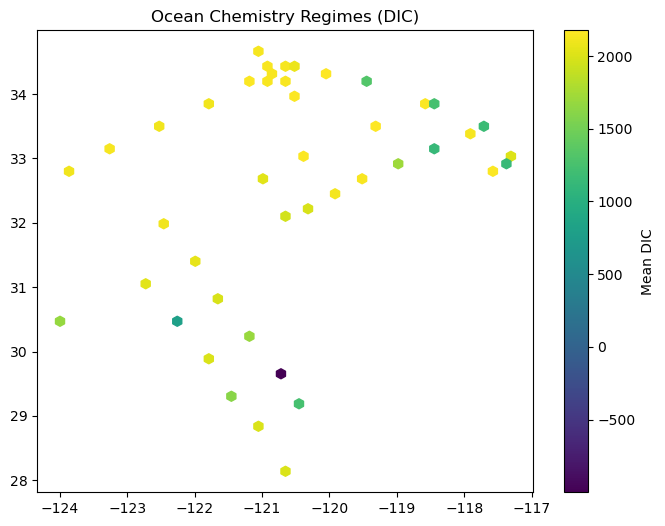

In [ ]:
plt.figure(figsize=(8,6))

plt.hexbin(
    chem_df['Longitude'],
    chem_df['Latitude'],
    C=chem_df['DIC'],
    reduce_C_function=np.mean,
    gridsize=50,
    cmap='viridis'
)

plt.colorbar(label="Mean DIC")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Ocean Chemistry Regimes (DIC)")
plt.show()

A scatterplot was used here to show average DIC levels across the ocean they collected samples from. The DIC plot here shows a clear spatial structure, indicating distinct chemical regimes across the study area.

### Overlay: Observations on DIC Map

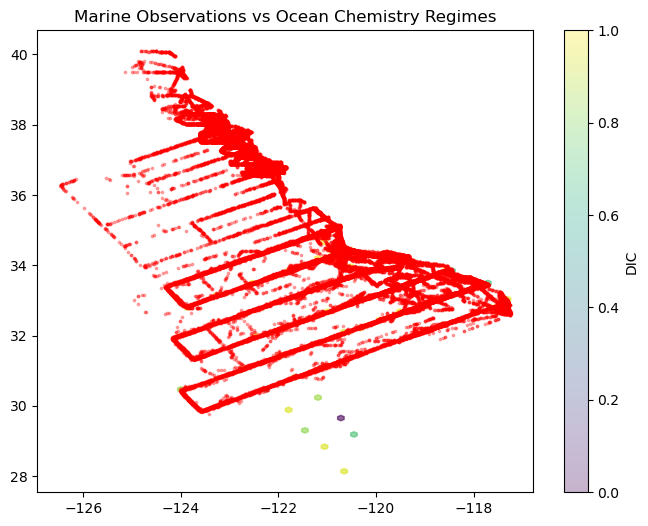

In [ ]:
plt.figure(figsize=(9,7))

hb = plt.hexbin(
    chem_df['Longitude'],
    chem_df['Latitude'],
    C=chem_df['DIC'],
    reduce_C_function=np.mean,
    gridsize=60,
    cmap='viridis',
    mincnt=5,
    linewidths=0
)

plt.plot(
    seamap_df['longitude'],
    seamap_df['latitude'],
    color='white',
    linewidth=0.3,
    alpha=0.2
)

cb = plt.colorbar(hb)
cb.set_label("DIC")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Marine Observations vs Ocean Chemistry Regimes")

plt.tight_layout()
plt.show()

An overlay on the heatmap made previously was used to show how 
Observations tend to cluster within specific chemical regions, suggesting a potential relationship between the observations on the marine life and DIC conditions.

### Relationship between observations and chemistry

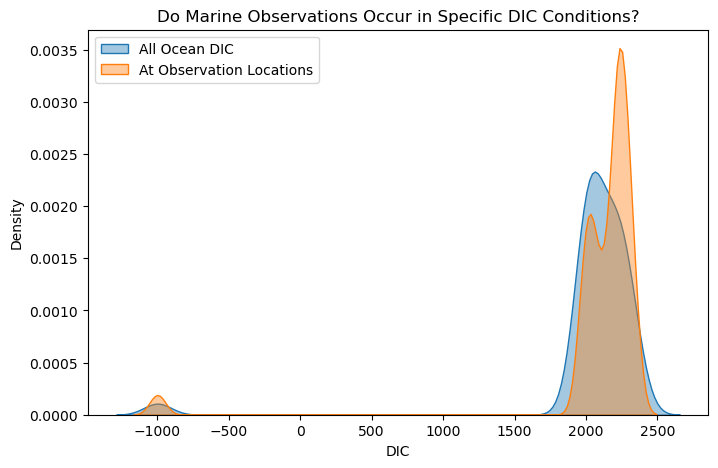

In [ ]:
chem_coords = np.column_stack((chem_df['Latitude'], chem_df['Longitude']))
tree = cKDTree(chem_coords)
bio_coords = np.column_stack((seamap_df['latitude'], seamap_df['longitude']))
dist, idx = tree.query(bio_coords, k=1)
seamap_df['matched_DIC'] = chem_df.iloc[idx]['DIC'].values

plt.figure(figsize=(8,5))

sns.kdeplot(chem_df['DIC'], label='All Ocean DIC', fill=True, alpha=0.4)
sns.kdeplot(seamap_df['matched_DIC'], label='At Observation Locations', fill=True, alpha=0.4)

plt.xlabel("DIC")
plt.ylabel("Density")
plt.title("Do Marine Observations Occur in Specific DIC Conditions?")
plt.legend()
plt.show()

The DIC distribution at observation locations is shifted toward different values compared to the background ocean. This suggests that marine observations are not randomly distributed, but instead occur preferentially under specific chemical conditions.

## Conclusion

The DIC levels at the observation locations are not aligned with how they measured DIC levels in other parts of the same ocean. Therefore there is some sampling bias in where they chose to observe marine life, and as a result there is a sampling error. This can affect future action taken from this data because this is not an accurate representation of marine life in different areas of the ocean.

Future work could incorporate species-level differences like looking at just seabirds or turtles etc and in a higher variety of parts of the ocean, particularly with varying DIC levels